# Prompts used for the code
Several ChatGPT prompts were used for the creation of this code and debugging.

The original prompt was along the lines of: "How can I read a pdf document and make training data for a LLM from it?".

This gave the base for the code, but several more propmts were using for debugging and fine-tuning the code to improve accuracy, for instance.

Some code from previous exercises was also used in this code (Graphs at the end, for instance).


In [ ]:
# Tuodaan tiedosto jupyter notebookiin, kysytty AI:lta apua
from google.colab import files

uploaded = files.upload()

Saving Deep_Learning_with_Python_Second_Editio.pdf to Deep_Learning_with_Python_Second_Editio.pdf


In [ ]:
# Convertataan pdf-tiedosto tekstiksi
!pip install pdfplumber

import pdfplumber
import numpy as np

file_path = "Deep_Learning_with_Python_Second_Editio.pdf"

text = ""

with pdfplumber.open(file_path) as pdf:
    for page in pdf.pages:
        text += page.extract_text() + "\n"

print(text[:1000])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 145.9 MB/s eta 0:00:00
SECOND EDITION
François Chollet
M A N N I N G
Deep Learning with Python
Licensed to kari Jyrkkä <kari.jyrkka@oamk.fi>
Licensed to kari Jyrkkä <kari.jyrkka@oamk.fi>
Deep Learning
with Python
SECOND EDITION
FRANÇOIS CHOLLET
MANNING
SHELTER ISLAND
Licensed to kari Jyrkkä <kari.jyrkka@oamk.fi>
For online information and ordering of this and other Manning books, please visit
www.manning.com. The publisher offers discounts on this book when ordered in quantity.
For more information, please contact
Special Sales Department
Manning Publications Co.
20 Baldwin Road
PO Box 761
Shelter Island, NY 11964
Email: 

In [ ]:
# Puhdistetaan tekstiä
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)          # remove numbers
    text = re.sub(r'[^\w\s]', '', text)      # remove punctuation
    return text

cleaned_text = clean_text(text)

In [ ]:
# Ladataan tiktokenizer
!pip install tiktoken

In [ ]:
# Importataan tiktokenizer
import tiktoken

# Choose encoding (important!)
enc = tiktoken.get_encoding("p50k_base")

In [ ]:
# Muutetaan teksti tokeneiksi
tokens = enc.encode(cleaned_text)

print("Total tokens:", len(tokens))
print(tokens[:20])  # preview

Total tokens: 230863
[12227, 8313, 198, 69, 2596, 16175, 10924, 442, 349, 1616, 198, 76, 257, 299, 299, 1312, 299, 308, 198, 22089]


In [ ]:
# Tehdään 80/20 validaatiodata
import random
random.seed(42)

# 80/20 validaatio
split_idx = int(len(tokens) * 0.8)

# Määritetään train_tokens ja val_tokens
train_tokens = tokens[:split_idx]
val_tokens = tokens[split_idx:]

# Printataan train size ja validation size
print("Train size:", len(train_tokens))
print("Validation size:", len(val_tokens))

Train size: 184690
Validation size: 46173


In [ ]:
# Tehdään chunkeiksi
def chunk_tokens(tokens, chunk_size=101, step=10, pad_token=0):
    """
    Break tokens into chunks for training.

    Args:
        tokens (list[int]): List of token IDs.
        chunk_size (int): Number of tokens per chunk.
        step (int): Overlap.
        pad_token (int): Token ID to pad the last chunk if needed.

    Returns:
        List of token chunks (list of lists).
    """
    chunks = []
    for i in range(0, len(tokens) - chunk_size + 1, step):
        chunk = tokens[i:i + chunk_size]
        chunks.append(chunk)
    # Pad the last chunk if needed
    if len(tokens) % chunk_size != 0:
        last_chunk = tokens[-chunk_size:]
        last_chunk = last_chunk + [pad_token] * (chunk_size - len(last_chunk))
        chunks.append(last_chunk)
    return np.array(chunks, dtype=np.int32)

train_token_chunks = chunk_tokens(train_tokens, 101, step=10)
val_token_chunks = chunk_tokens(val_tokens, 101, step=101)  # non-overlapping for validation

text_chunks = [enc.decode(chunk) for chunk in train_token_chunks]

print("Chunks:", len(text_chunks))

Chunks: 18460


In [ ]:
train_sequences = []
val_sequences = []

def make_sequences(token_chunks):
    sequences = []
    for chunk in token_chunks:
        input_seq = chunk[:-1]   # first 100 tokens
        target_seq = chunk[1:]   # shifted by 1
        sequences.append({
            "input": input_seq,
            "target": target_seq
        })
    return sequences

    val_sequences.append({
        "input": input_seq,
        "target": target_seq
    })

train_sequences = make_sequences(train_token_chunks)
val_sequences = make_sequences(val_token_chunks)

X_train = np.array([item["input"] for item in train_sequences])
y_train = np.array([item["target"] for item in train_sequences])

X_val = np.array([item["input"] for item in val_sequences])
y_val = np.array([item["target"] for item in val_sequences])

In [ ]:
print(X_train.shape)  # (num_samples, 100)

(18460, 100)


In [ ]:
# Importataan tensorflow yms. ja muutetaan training data oikean tyyppiseksi modelin rakentamiseen
import tensorflow as tf
from tensorflow.keras import layers

#vocab_size = 100000  # safe default for cl100k_base
#vocab_size = 20000  # or even 10000
vocab_size = 50281
seq_length = X_train.shape[1]

# Make sure all the tokens are valid by clipping
X_train = np.clip(X_train, 0, vocab_size - 1)
y_train = np.clip(y_train, 0, vocab_size - 1)
X_val = np.clip(X_val, 0, vocab_size - 1)
y_val = np.clip(y_val, 0, vocab_size - 1)

X_train = X_train.astype("int32")
y_train = y_train.astype("int32")
X_val = X_val.astype("int32")
y_val = y_val.astype("int32")

# Use only the last token in each sequence as target
y_train = y_train[:, -1]
y_val = y_val[:, -1]

In [ ]:
# Tehdään model
model = tf.keras.Sequential([
    #layers.Embedding(input_dim=vocab_size, output_dim=64, input_length=seq_length),
    #layers.Embedding(input_dim=vocab_size, output_dim=64),
    #layers.LSTM(128, return_sequences=True),
    # Lighter version
    layers.Embedding(input_dim=vocab_size, output_dim=16, input_length=100),
    layers.Conv1D(filters=128, kernel_size=3, padding="same", activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dense(vocab_size, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.build(input_shape=(None, seq_length))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │       804,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 128)       │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50281)          │     3,268,265 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,087,289 (15.59 MB)

 Trainable params: 4,087,289 (15.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Koulutetaan model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=10
)

Epoch 1/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.0847 - loss: 7.4621 - val_accuracy: 0.1070 - val_loss: 7.1517
Epoch 2/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0849 - loss: 6.6190 - val_accuracy: 0.1070 - val_loss: 7.2738
Epoch 3/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0849 - loss: 6.5112 - val_accuracy: 0.1070 - val_loss: 7.3919
Epoch 4/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0849 - loss: 6.4644 - val_accuracy: 0.1070 - val_loss: 7.3807
Epoch 5/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0855 - loss: 6.3765 - val_accuracy: 0.1004 - val_loss: 7.3513
Epoch 6/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0906 - loss: 6.1822 - val_accuracy: 0.0939 - val_loss: 7.3966
Epoch 7/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0924 - loss: 6.0500 - val_accuracy: 0.0961 - val_loss: 7.4995
Epoch 8/10
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0940 - loss: 5.9622 -

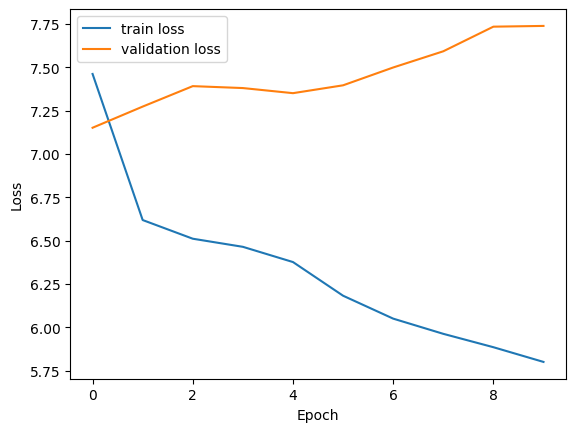

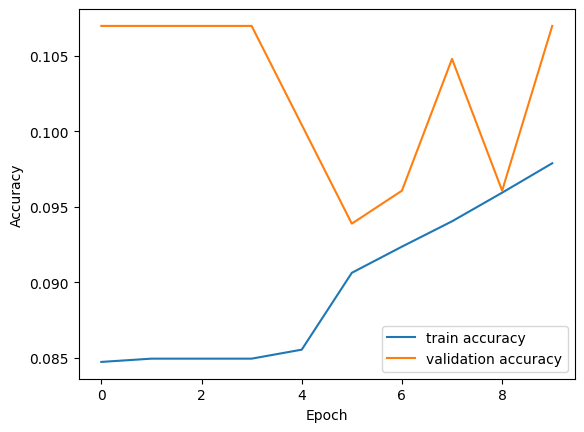

In [ ]:
# Graph code from previous exercises
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()